<a href="https://colab.research.google.com/github/jabsolo73/Data-Processing-teachings/blob/main/Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exploring Seaborn: Styles, Plots, and Customization

This section will guide you through various aspects of the Seaborn library, including its built-in styles, common plot types, and how to use them with sample data.

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib

print(f"Seaborn version: {sns.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Pandas version: {pd.__version__}")

Seaborn version: 0.13.2
Matplotlib version: 3.10.0
Pandas version: 2.2.2


### 1. Seaborn Styles

Seaborn comes with several built-in styles that can be applied to plots to quickly change their aesthetic. You can see the available styles using `sns.set_style()` or `sns.axes_style()`.

Let's visualize a simple plot with different styles.

Available Seaborn styles: ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']


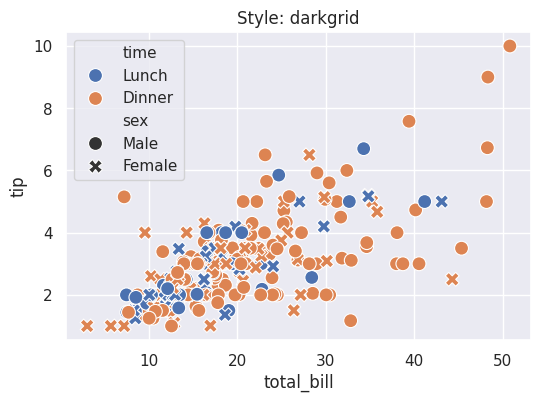

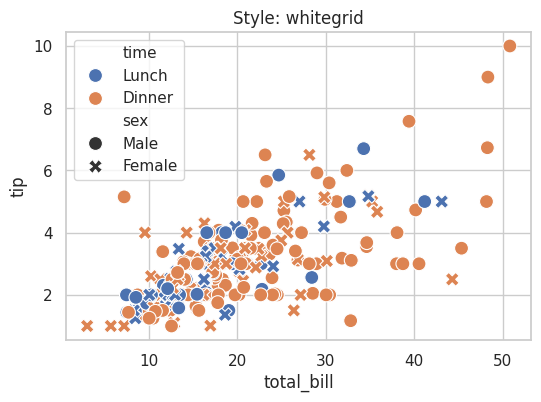

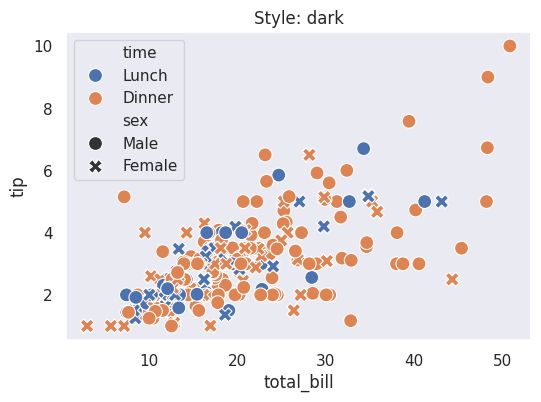

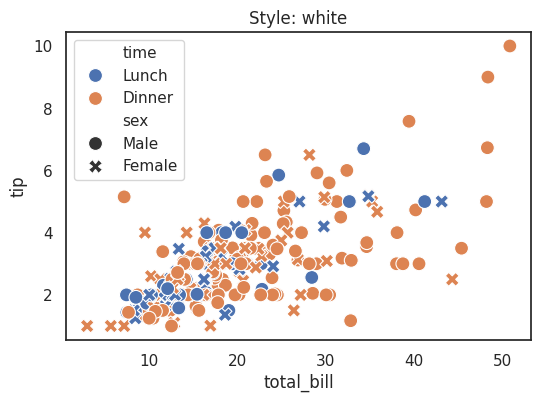

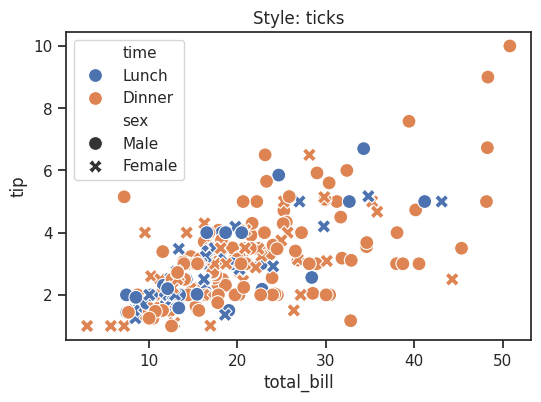

In [16]:
# Load a sample dataset for demonstration
tips = sns.load_dataset("tips")

# Explicitly define standard Seaborn styles
styles_names = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
print("Available Seaborn styles:", styles_names)

# Function to create a simple plot
def create_simple_plot(data, style_name):
    plt.figure(figsize=(6, 4))
    sns.set_style(style_name)
    sns.scatterplot(x="total_bill", y="tip", data=data, hue="time", style="sex", s=100)
    plt.title(f"Style: {style_name}")
    plt.show()

# Apply and visualize different styles
for style in styles_names:
    create_simple_plot(tips, style)

### 2. Common Seaborn Plot Types and Their Usage

Seaborn offers a wide range of plotting functions, categorized into relational, distributional, categorical, and regression plots. Here's a demonstration of some key plot types with their basic syntax and common arguments.

We'll use sample datasets like `tips`, `iris`, and `flights`.

In [3]:
sns.set_theme() # Reset to default Seaborn theme

# Load more sample datasets
iris = sns.load_dataset("iris")
flights = sns.load_dataset("flights")

print("\n--- Sample Data: Tips ---")
display(tips.head())
print("\n--- Sample Data: Iris ---")
display(iris.head())
print("\n--- Sample Data: Flights ---")
display(flights.head())


--- Sample Data: Tips ---


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



--- Sample Data: Iris ---


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



--- Sample Data: Flights ---


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


#### 2.1 Relational Plots (`relplot`, `scatterplot`, `lineplot`)

These plots visualize the statistical relationship between two variables. `relplot` is a figure-level function that can draw `scatterplot` or `lineplot` with faceting.

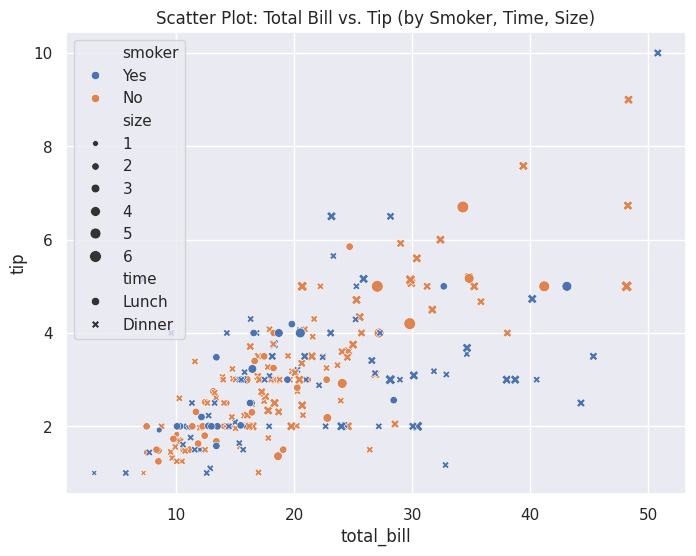

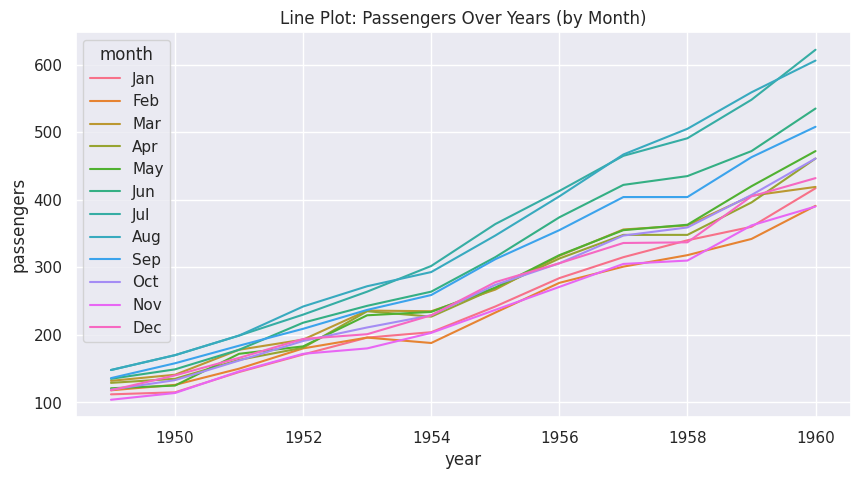

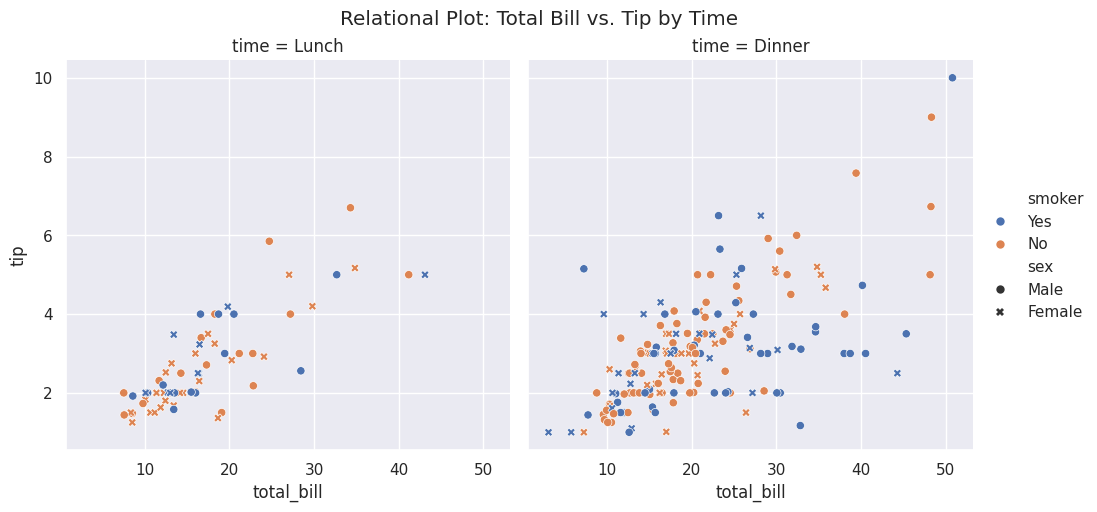

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="total_bill", y="tip", data=tips, hue="smoker", style="time", size="size")
plt.title("Scatter Plot: Total Bill vs. Tip (by Smoker, Time, Size)")
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(x="year", y="passengers", data=flights, hue="month")
plt.title("Line Plot: Passengers Over Years (by Month)")
plt.show()

# Using relplot for faceting
sns.relplot(x="total_bill", y="tip", data=tips, col="time", hue="smoker", style="sex", kind="scatter")
plt.suptitle("Relational Plot: Total Bill vs. Tip by Time", y=1.02) # Adjust suptitle position
plt.show()

#### 2.2 Distributional Plots (`displot`, `histplot`, `kdeplot`, `ecdfplot`, `rugplot`)

These plots show the distribution of a single variable or the joint distribution of two variables.

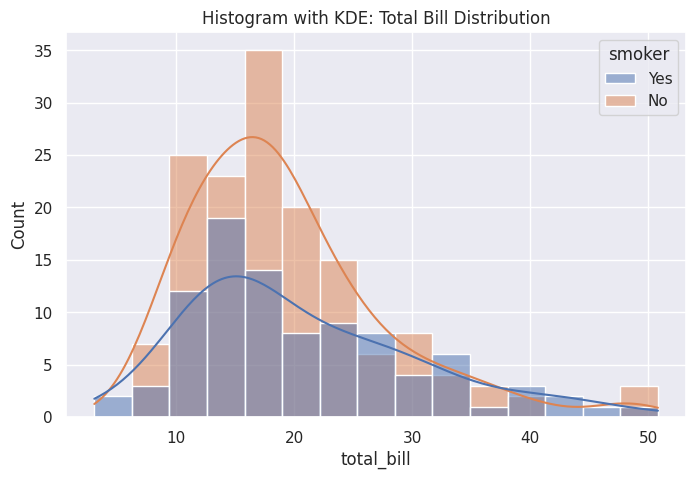

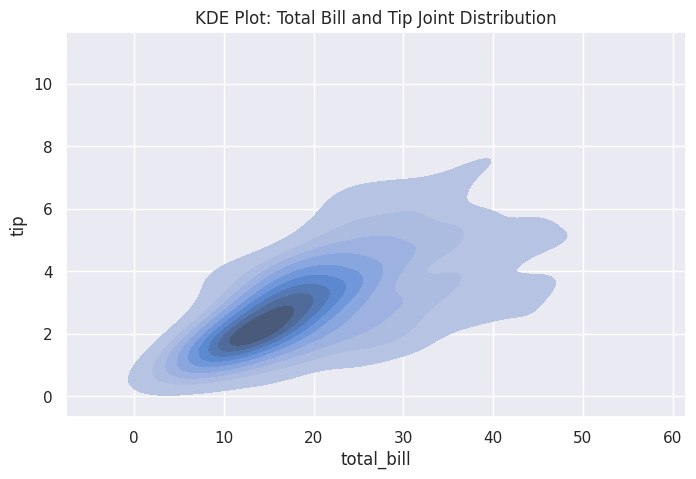

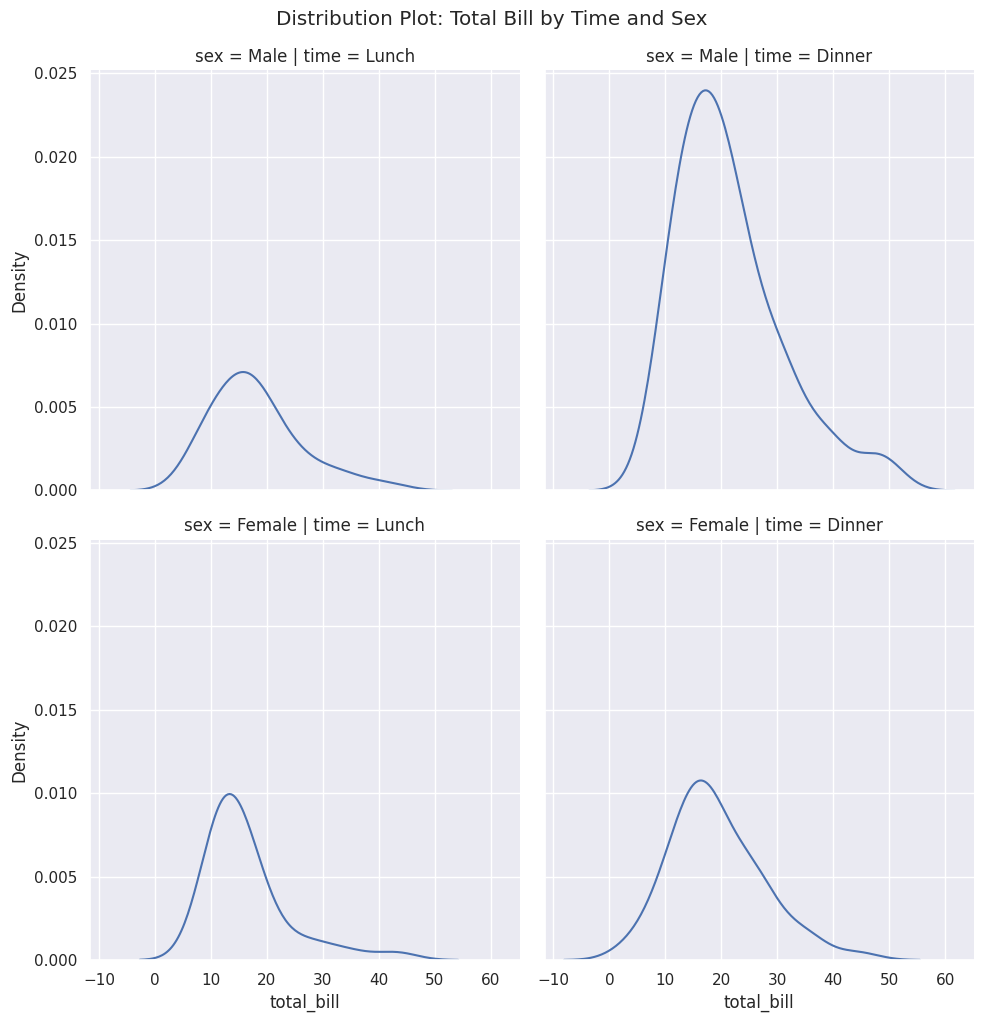

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(x="total_bill", data=tips, bins=15, kde=True, hue="smoker")
plt.title("Histogram with KDE: Total Bill Distribution")
plt.show()

plt.figure(figsize=(8, 5))
sns.kdeplot(x="total_bill", y="tip", data=tips, fill=True)
plt.title("KDE Plot: Total Bill and Tip Joint Distribution")
plt.show()

# Using displot for faceting/different kinds
sns.displot(data=tips, x="total_bill", col="time", row="sex", kind="kde")
plt.suptitle("Distribution Plot: Total Bill by Time and Sex", y=1.02)
plt.show()

#### 2.3 Categorical Plots (`catplot`, `boxplot`, `violinplot`, `stripplot`, `swarmplot`, `barplot`, `countplot`)

These plots show the relationship between a numerical and one or more categorical variables.

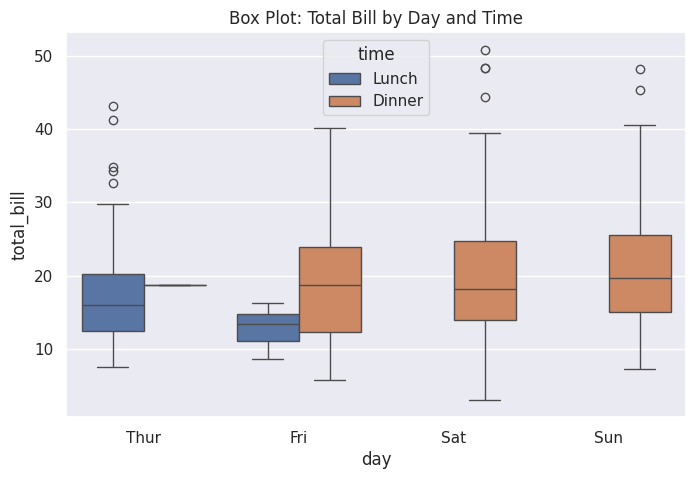

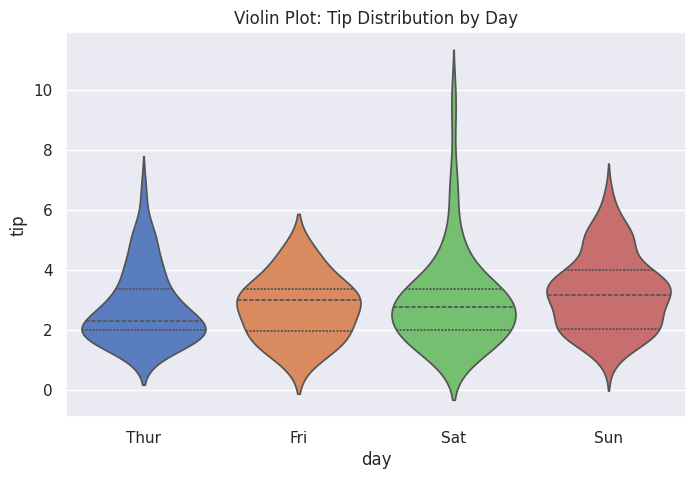

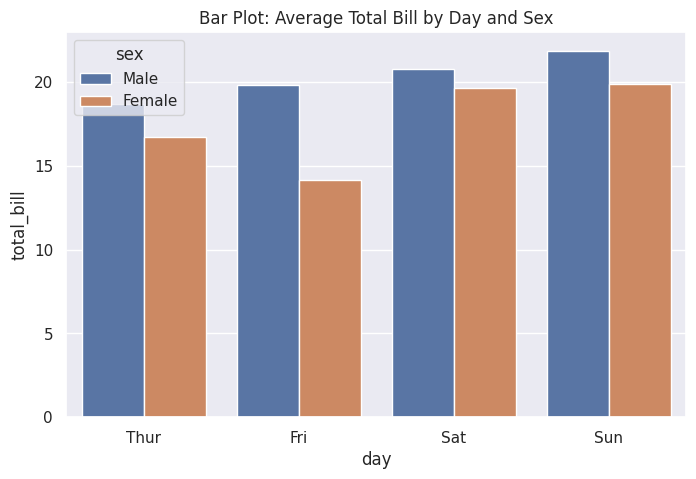

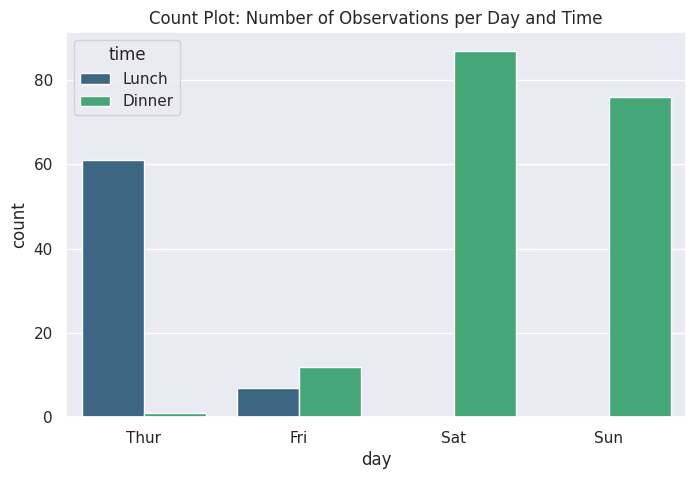

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 9.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.0% of the points cannot be placed; 

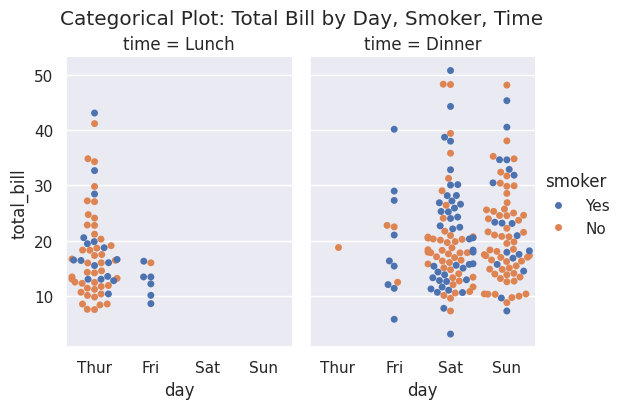

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="day", y="total_bill", data=tips, hue="time")
plt.title("Box Plot: Total Bill by Day and Time")
plt.show()

plt.figure(figsize=(8, 5))
sns.violinplot(x="day", y="tip", data=tips, hue="day", legend=False, inner="quart", palette="muted")
plt.title("Violin Plot: Tip Distribution by Day")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x="day", y="total_bill", data=tips, errorbar=None, hue="sex")
plt.title("Bar Plot: Average Total Bill by Day and Sex")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x="day", data=tips, hue="time", palette="viridis")
plt.title("Count Plot: Number of Observations per Day and Time")
plt.show()

# Using catplot for faceting
sns.catplot(x="day", y="total_bill", hue="smoker", col="time", data=tips, kind="swarm", height=4, aspect=0.7)
plt.suptitle("Categorical Plot: Total Bill by Day, Smoker, Time", y=1.02)
plt.show()

#### 2.4 Regression Plots (`regplot`, `lmplot`)

These plots show a linear regression model fit along with its confidence interval.

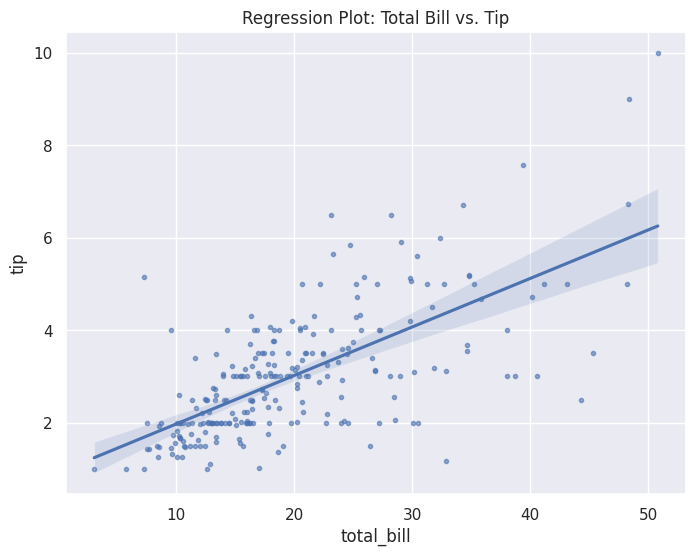

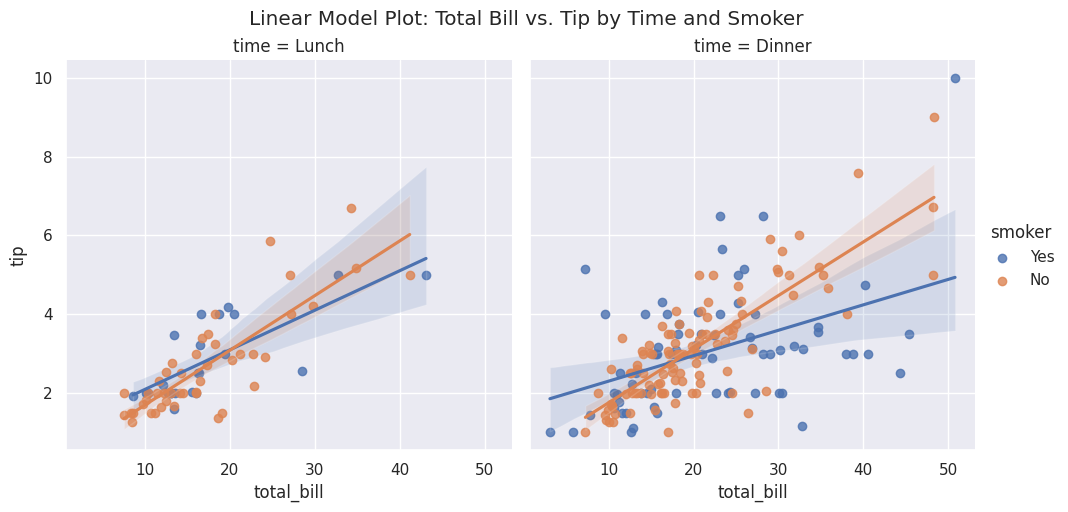

In [7]:
plt.figure(figsize=(8, 6))
sns.regplot(x="total_bill", y="tip", data=tips, marker=".", scatter_kws={'alpha':0.6})
plt.title("Regression Plot: Total Bill vs. Tip")
plt.show()

# Using lmplot for faceting with regression
sns.lmplot(x="total_bill", y="tip", data=tips, col="time", hue="smoker", ci=95)
plt.suptitle("Linear Model Plot: Total Bill vs. Tip by Time and Smoker", y=1.02)
plt.show()

#### 2.5 Matrix Plots (`heatmap`, `clustermap`)

These are useful for visualizing matrices of data, such as correlation matrices or pivot tables.

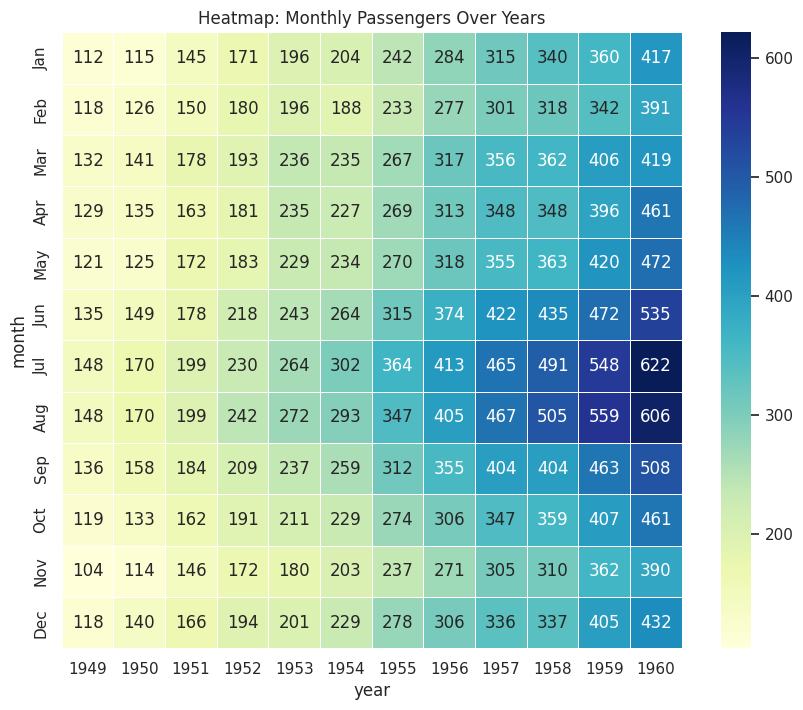

<Figure size 1000x800 with 0 Axes>

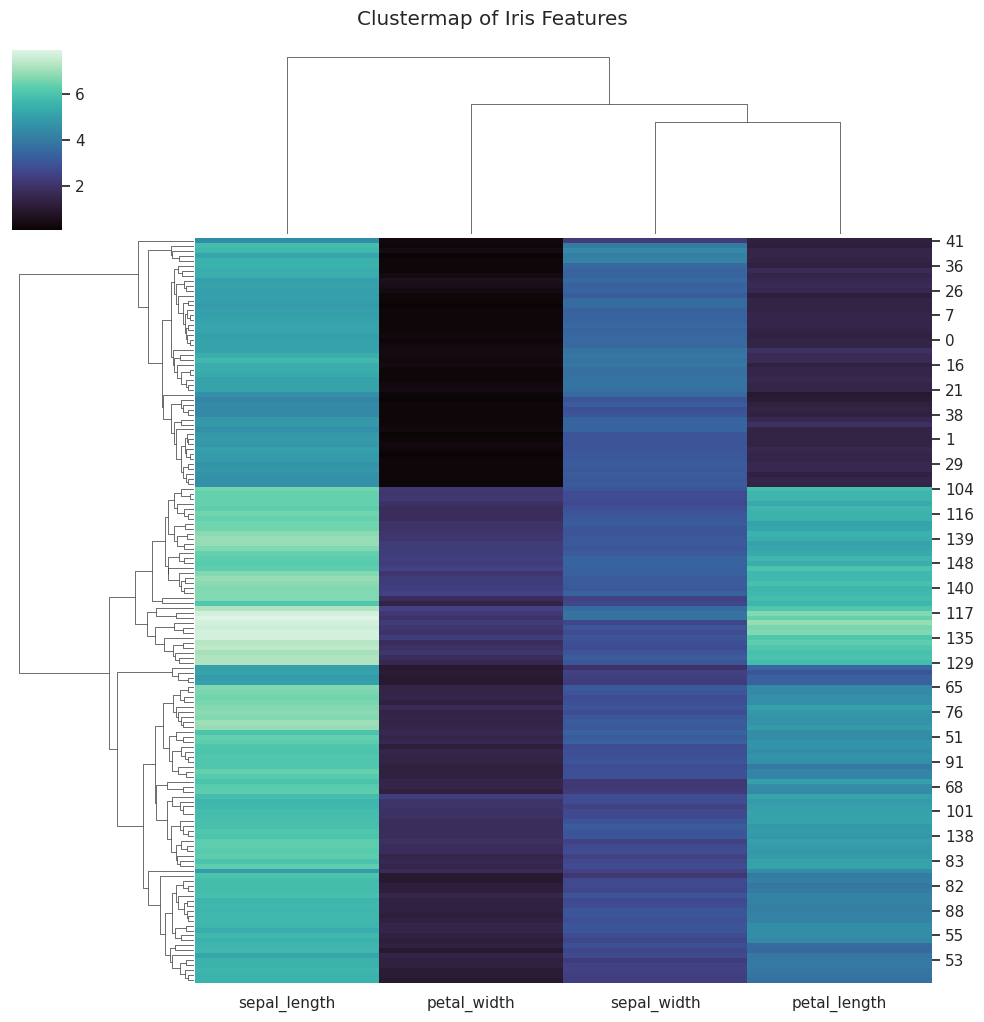

In [13]:
# Pivot the flights dataset for heatmap
flights_pivot = flights.pivot_table(values='passengers', index='month', columns='year', observed=False)

plt.figure(figsize=(10, 8))
sns.heatmap(flights_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap: Monthly Passengers Over Years")
plt.show()

# Clustermap for hierarchical clustering
plt.figure(figsize=(10, 8))
sns.clustermap(iris.drop("species", axis=1), cmap="mako")
plt.suptitle("Clustermap of Iris Features", y=1.02)
plt.show()

#### 2.6 Multi-Plot Grids (`PairGrid`, `FacetGrid`)

Seaborn also provides tools for drawing multiple plots on a single figure, which are very powerful for exploring relationships across many variables or categories.

*   **`PairGrid`** and **`pairplot`**: For visualizing relationships between all pairs of variables in a dataset.
*   **`FacetGrid`**: For structuring grids of plots based on the levels of variables in a dataset.

In [15]:
# Load a sample dataset for demonstration
tips = sns.load_dataset("tips")

# Available styles
print("Available Seaborn styles:", sns.get_styles())

# Function to create a simple plot
def create_simple_plot(data, style_name):
    plt.figure(figsize=(6, 4))
    sns.set_style(style_name)
    sns.scatterplot(x="total_bill", y="tip", data=data, hue="time", style="sex", s=100)
    plt.title(f"Style: {style_name}")
    plt.show()

# Apply and visualize different styles
styles = sns.get_styles()
for style in styles:
    create_simple_plot(tips, style)

AttributeError: module 'seaborn' has no attribute 'get_styles'

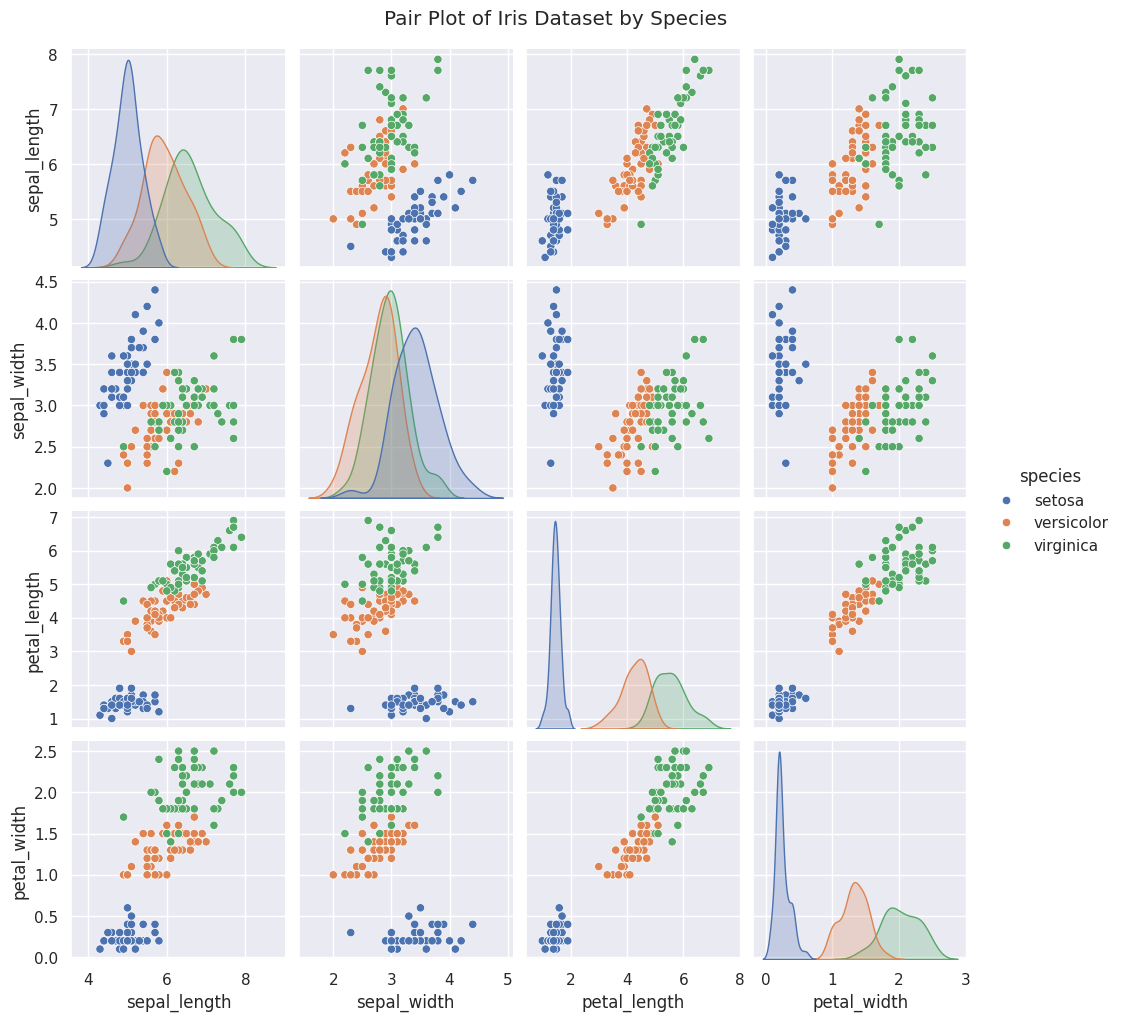

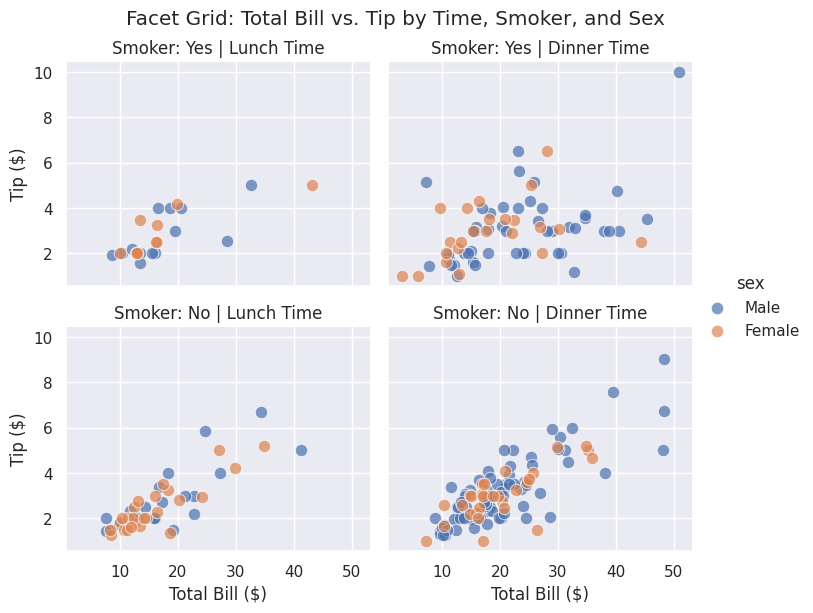

In [9]:
# Using pairplot
sns.pairplot(iris, hue="species", palette="deep")
plt.suptitle("Pair Plot of Iris Dataset by Species", y=1.02) # Adjust suptitle position
plt.show()

# Using FacetGrid for custom multi-plot layouts
g = sns.FacetGrid(tips, col="time", row="smoker", hue="sex", height=3, aspect=1.2)
g.map(sns.scatterplot, "total_bill", "tip", s=80, alpha=.7)
g.add_legend()
g.set_axis_labels("Total Bill ($)", "Tip ($)")
g.set_titles(col_template="{col_name} Time", row_template="Smoker: {row_name}")
plt.suptitle("Facet Grid: Total Bill vs. Tip by Time, Smoker, and Sex", y=1.02)
plt.show()